# Clothing extraction from model photos

**Goal:** experiment with non-LLM garment extraction from photos of people wearing clothes.

**What this notebook compares**
1. **FASHN Human Parser** (`fashn-ai/fashn-human-parser`) for fashion-aware semantic parsing.
2. **SCHP (ATR)** (`pirocheto/schp-atr-18`) for human parsing with clothing labels.
3. **SegFormer clothes** (`mattmdjaga/segformer_b2_clothes`) as a lightweight fashion segmentation baseline.
4. **SAM box refinement** (`facebook/sam-vit-base`) to sharpen parser masks into cleaner item cutouts.
5. **Optional Detectron2 hook** for a user-supplied fashion checkpoint.

**Setup note:** install the repo requirements first. `torchvision` is required by the Hugging Face vision processors used here.

**Practical note:** the SCHP backend uses remote code and is more likely to have environment-specific issues. The default experiment starts with the safer pure-Transformers backends first.

**Input:** model-worn photos in `notebooks/model_images/` (falls back to `notebooks/images/` if empty).

**Output:** extracted garment PNGs in `notebooks/outputs/clothes_extraction/<backend>/<image-stem>/`.

**Notebook layout**
1. **Helpers** — paths, plotting, crop/export utilities.
2. **Fashion segmentation backends** — FASHN parser, SCHP ATR, SegFormer clothes.
3. **SAM refinement** — box-prompted mask sharpening from coarse parser masks.
4. **Single-image demo** — run several backends and inspect overlays/crops.
5. **Batch export** — process an entire folder and write a manifest.
6. **Optional Detectron2** — plug in a DeepFashion/ModaNet-style checkpoint if you have one.


In [8]:
from __future__ import annotations

import json
import math
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from transformers import (
    AutoImageProcessor,
    AutoModelForSemanticSegmentation,
    SamModel,
    SamProcessor,
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
)


def project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "AGENTS.md").is_file():
            return candidate
    return cwd


ROOT = project_root()
NOTEBOOKS_DIR = ROOT / "notebooks" if (ROOT / "notebooks").is_dir() else ROOT
MODEL_IMAGE_DIR = NOTEBOOKS_DIR / "model_images"
FALLBACK_IMAGE_DIR = NOTEBOOKS_DIR / "images"
OUTPUT_DIR = NOTEBOOKS_DIR / "outputs" / "clothes_extraction"

for path in (MODEL_IMAGE_DIR, OUTPUT_DIR):
    path.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"ROOT={ROOT}")
print(f"DEVICE={DEVICE}")
print(f"MODEL_IMAGE_DIR={MODEL_IMAGE_DIR}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")


def ensure_torchvision_available() -> None:
    try:
        import torchvision  # noqa: F401
    except Exception as exc:
        raise ImportError(
            "This notebook requires torchvision. Install dependencies with `pip install -r requirements.txt` "
            "or install a torch/torchvision pair that matches your environment, then restart the kernel."
        ) from exc


ensure_torchvision_available()


def backend_error_message(backend_name: str, exc: Exception) -> str:
    message = str(exc)
    if "CUDA_HOME environment variable is not set" in message:
        return (
            f"{backend_name} failed because the current environment is trying to compile or load CUDA components. "
            "For this notebook, use a CPU/MPS-friendly torch install and restart the kernel. "
            "If you only want the notebook working quickly, skip this backend and keep the pure Transformers ones enabled."
        )
    if isinstance(exc, ImportError):
        return f"{backend_name} import failed: {message}"
    return f"{backend_name} failed: {exc.__class__.__name__}: {message}"


def image_paths(image_dir: Path) -> list[Path]:
    if not image_dir.exists():
        return []
    exts = {".jpg", ".jpeg", ".png", ".webp"}
    return [p for p in sorted(image_dir.iterdir()) if p.is_file() and p.suffix.lower() in exts]


def first_image_path(*dirs: Path) -> Path | None:
    for directory in dirs:
        paths = image_paths(directory)
        if paths:
            return paths[0]
    return None


def load_image(path: str | Path) -> Image.Image:
    return Image.open(Path(path)).convert("RGB")


ROOT=/Users/mohitjoshi/Projects/fashion-app
DEVICE=cpu
MODEL_IMAGE_DIR=/Users/mohitjoshi/Projects/fashion-app/notebooks/model_images
OUTPUT_DIR=/Users/mohitjoshi/Projects/fashion-app/notebooks/outputs/clothes_extraction


## Helpers: masks, overlays, crops, exports


In [9]:
LABEL_COLORS: dict[str, tuple[int, int, int]] = {
    "top": (240, 99, 73),
    "dress": (69, 123, 157),
    "skirt": (29, 185, 84),
    "pants": (247, 183, 49),
    "belt": (118, 93, 105),
    "scarf": (87, 117, 144),
    "shoes": (84, 13, 110),
}


def to_numpy_mask(mask: Any) -> np.ndarray:
    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()
    return np.asarray(mask).astype(bool)


def bbox_from_mask(mask: np.ndarray, pad: int = 0) -> list[int] | None:
    mask = to_numpy_mask(mask)
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    y0 = max(0, int(ys.min()) - pad)
    y1 = int(ys.max()) + 1 + pad
    x0 = max(0, int(xs.min()) - pad)
    x1 = int(xs.max()) + 1 + pad
    return [x0, y0, x1, y1]


def mask_iou(a: np.ndarray, b: np.ndarray) -> float:
    a = to_numpy_mask(a)
    b = to_numpy_mask(b)
    union = np.logical_or(a, b).sum()
    if union == 0:
        return 0.0
    return float(np.logical_and(a, b).sum() / union)


def crop_rgba(image: Image.Image, mask: np.ndarray, pad: int = 4) -> Image.Image | None:
    mask = to_numpy_mask(mask)
    box = bbox_from_mask(mask, pad=pad)
    if box is None:
        return None
    x0, y0, x1, y1 = box
    image_arr = np.asarray(image)
    crop_rgb = image_arr[y0:y1, x0:x1]
    crop_mask = mask[y0:y1, x0:x1]
    rgba = np.dstack([crop_rgb, crop_mask.astype(np.uint8) * 255])
    return Image.fromarray(rgba, mode="RGBA")


def crop_on_white(image: Image.Image, mask: np.ndarray, pad: int = 4) -> Image.Image | None:
    mask = to_numpy_mask(mask)
    box = bbox_from_mask(mask, pad=pad)
    if box is None:
        return None
    x0, y0, x1, y1 = box
    image_arr = np.asarray(image)
    crop_rgb = image_arr[y0:y1, x0:x1]
    crop_mask = mask[y0:y1, x0:x1]
    white = np.full_like(crop_rgb, 255)
    white[crop_mask] = crop_rgb[crop_mask]
    return Image.fromarray(white, mode="RGB")


def overlay_masks(image: Image.Image, items: dict[str, np.ndarray], alpha: float = 0.42) -> np.ndarray:
    base = np.asarray(image).astype(np.float32).copy()
    for label, mask in items.items():
        mask = to_numpy_mask(mask)
        color = np.asarray(LABEL_COLORS.get(label, (255, 0, 0)), dtype=np.float32)
        base[mask] = base[mask] * (1.0 - alpha) + color * alpha
    return base.astype(np.uint8)


def summarize_items(items: dict[str, np.ndarray]) -> dict[str, int]:
    return {label: int(to_numpy_mask(mask).sum()) for label, mask in items.items()}


def show_extractions(image: Image.Image, items: dict[str, np.ndarray], title: str) -> None:
    cards: list[tuple[str, np.ndarray]] = [
        ("original", np.asarray(image)),
        ("overlay", overlay_masks(image, items)),
    ]
    for label, mask in items.items():
        crop = crop_rgba(image, mask)
        if crop is not None:
            cards.append((label, np.asarray(crop)))

    cols = min(4, max(2, len(cards)))
    rows = math.ceil(len(cards) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 4.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    fig.suptitle(title, fontsize=14)

    for ax, (label, arr) in zip(axes, cards):
        ax.imshow(arr)
        ax.set_title(label)
        ax.axis("off")

    for ax in axes[len(cards):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def save_item_crops(
    image_path: Path,
    backend_name: str,
    image: Image.Image,
    items: dict[str, np.ndarray],
    output_dir: Path = OUTPUT_DIR,
) -> list[dict[str, Any]]:
    target_dir = output_dir / backend_name / image_path.stem
    target_dir.mkdir(parents=True, exist_ok=True)
    overlay_path = target_dir / "_overlay.png"
    Image.fromarray(overlay_masks(image, items)).save(overlay_path)

    records: list[dict[str, Any]] = []
    for label, mask in items.items():
        rgba = crop_rgba(image, mask)
        white = crop_on_white(image, mask)
        box = bbox_from_mask(mask)
        if rgba is None or white is None or box is None:
            continue

        rgba_path = target_dir / f"{label}.png"
        white_path = target_dir / f"{label}_white.png"
        rgba.save(rgba_path)
        white.save(white_path)
        records.append(
            {
                "source_image": str(image_path),
                "backend": backend_name,
                "label": label,
                "pixels": int(to_numpy_mask(mask).sum()),
                "bbox_xyxy": box,
                "rgba_path": str(rgba_path),
                "white_path": str(white_path),
                "overlay_path": str(overlay_path),
            }
        )
    return records


## Fashion segmentation backends


In [10]:
BACKEND_SPECS: dict[str, dict[str, Any]] = {
    "fashn_human_parser": {
        "checkpoint": "fashn-ai/fashn-human-parser",
        "label_map": {
            3: "top",
            4: "dress",
            5: "skirt",
            6: "pants",
            7: "belt",
            10: "scarf",
        },
        "processor_cls": "segformer",
        "model_cls": "segformer",
        "use_trust_remote_code": False
    },
    "schp_atr": {
        "checkpoint": "pirocheto/schp-atr-18",
        "label_map": {
            4: "top",
            5: "skirt",
            6: "pants",
            7: "dress",
            8: "belt",
            17: "scarf",
        },
        "processor_cls": "auto",
        "model_cls": "auto",
        "use_trust_remote_code": True
    },
    "segformer_b2_clothes": {
        "checkpoint": "mattmdjaga/segformer_b2_clothes",
        "label_map": {
            4: "top",
            5: "skirt",
            6: "pants",
            7: "dress",
            8: "belt",
            17: "scarf",
        },
        "processor_cls": "segformer",
        "model_cls": "auto",
        "use_trust_remote_code": False
    },
}

MODEL_CACHE: dict[str, dict[str, Any]] = {}


def load_semantic_backend(backend_name: str) -> dict[str, Any]:
    if backend_name in MODEL_CACHE:
        return MODEL_CACHE[backend_name]

    ensure_torchvision_available()

    spec = BACKEND_SPECS[backend_name]
    trust_remote_code = bool(spec.get("use_trust_remote_code", False))

    try:
        if spec["processor_cls"] == "segformer":
            processor = SegformerImageProcessor.from_pretrained(spec["checkpoint"])
        else:
            processor = AutoImageProcessor.from_pretrained(
                spec["checkpoint"],
                trust_remote_code=trust_remote_code,
            )

        if spec["model_cls"] == "segformer":
            model = SegformerForSemanticSegmentation.from_pretrained(spec["checkpoint"])
        else:
            model = AutoModelForSemanticSegmentation.from_pretrained(
                spec["checkpoint"],
                trust_remote_code=trust_remote_code,
            )
    except Exception as exc:
        raise RuntimeError(backend_error_message(backend_name, exc)) from exc

    model = model.to(DEVICE)
    model.eval()
    MODEL_CACHE[backend_name] = {"processor": processor, "model": model, **spec}
    return MODEL_CACHE[backend_name]


def predict_semantic_map(image: Image.Image, backend_name: str) -> np.ndarray:
    bundle = load_semantic_backend(backend_name)
    processor = bundle["processor"]
    model = bundle["model"]
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = getattr(outputs, "parsing_logits", None)
    if logits is None:
        logits = outputs.logits

    upsampled = F.interpolate(
        logits,
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False,
    )
    return upsampled.argmax(dim=1)[0].detach().cpu().numpy()


def semantic_items_from_map(
    seg_map: np.ndarray,
    backend_name: str,
    min_pixels: int = 600,
) -> dict[str, np.ndarray]:
    label_map = BACKEND_SPECS[backend_name]["label_map"]
    items: dict[str, np.ndarray] = {}
    for label_id, normalized_label in label_map.items():
        mask = seg_map == label_id
        if int(mask.sum()) < min_pixels:
            continue
        if normalized_label not in items:
            items[normalized_label] = np.zeros_like(mask, dtype=bool)
        items[normalized_label] |= mask
    return items


def run_semantic_backend(
    image: Image.Image,
    backend_name: str,
    min_pixels: int = 600,
) -> dict[str, Any]:
    seg_map = predict_semantic_map(image, backend_name)
    items = semantic_items_from_map(seg_map, backend_name, min_pixels=min_pixels)
    return {
        "backend": backend_name,
        "seg_map": seg_map,
        "items": items,
        "summary": summarize_items(items),
    }


def try_run_semantic_backend(
    image: Image.Image,
    backend_name: str,
    min_pixels: int = 600,
) -> tuple[dict[str, Any] | None, str | None]:
    try:
        return run_semantic_backend(image, backend_name, min_pixels=min_pixels), None
    except Exception as exc:
        return None, backend_error_message(backend_name, exc)


## SAM refinement

SAM is used here as a **mask sharpener** rather than a standalone clothing classifier. The semantic parser proposes the clothing region, and SAM refines the edges from a bounding box prompt.


In [11]:
SAM_CACHE: dict[str, dict[str, Any]] = {}
SAM_GENERATOR_CACHE: dict[str, Any] = {}


def load_sam_bundle(checkpoint: str = "facebook/sam-vit-base") -> dict[str, Any]:
    if checkpoint in SAM_CACHE:
        return SAM_CACHE[checkpoint]
    ensure_torchvision_available()
    processor = SamProcessor.from_pretrained(checkpoint)
    model = SamModel.from_pretrained(checkpoint).to(DEVICE)
    model.eval()
    SAM_CACHE[checkpoint] = {"processor": processor, "model": model}
    return SAM_CACHE[checkpoint]


def post_process_sam_masks(processor: SamProcessor, pred_masks: torch.Tensor, inputs: dict[str, Any]) -> Any:
    try:
        return processor.image_processor.post_process_masks(
            pred_masks.cpu(),
            inputs["original_sizes"].cpu(),
            inputs["reshaped_input_sizes"].cpu(),
        )
    except TypeError:
        return processor.image_processor.post_process_masks(
            pred_masks.cpu(),
            inputs["original_sizes"].cpu(),
        )


def sam_candidates_from_box(
    image: Image.Image,
    box: list[int],
    checkpoint: str = "facebook/sam-vit-base",
) -> tuple[list[np.ndarray], np.ndarray]:
    bundle = load_sam_bundle(checkpoint)
    processor = bundle["processor"]
    model = bundle["model"]
    inputs = processor(image, input_boxes=[[[box]]], return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    masks = post_process_sam_masks(processor, outputs.pred_masks, inputs)[0][0]
    scores = outputs.iou_scores[0][0].detach().cpu().numpy()
    candidates = [to_numpy_mask(mask) for mask in masks]
    return candidates, scores


def refine_items_with_sam(
    image: Image.Image,
    coarse_items: dict[str, np.ndarray],
    checkpoint: str = "facebook/sam-vit-base",
) -> tuple[dict[str, np.ndarray], list[dict[str, Any]]]:
    refined: dict[str, np.ndarray] = {}
    details: list[dict[str, Any]] = []

    for label, coarse_mask in coarse_items.items():
        coarse_mask = to_numpy_mask(coarse_mask)
        box = bbox_from_mask(coarse_mask, pad=12)
        if box is None:
            continue

        candidates, sam_scores = sam_candidates_from_box(image, box, checkpoint=checkpoint)
        if not candidates:
            refined[label] = coarse_mask
            continue

        ranked = []
        for idx, candidate in enumerate(candidates):
            overlap = mask_iou(candidate, coarse_mask)
            score = overlap * 0.8 + float(sam_scores[idx]) * 0.2
            ranked.append((score, overlap, idx, candidate))

        ranked.sort(reverse=True, key=lambda row: row[0])
        _, best_overlap, best_idx, best_mask = ranked[0]
        if best_overlap < 0.05 or best_mask.sum() > coarse_mask.sum() * 4:
            best_mask = coarse_mask

        refined[label] = best_mask
        details.append(
            {
                "label": label,
                "box_xyxy": box,
                "coarse_pixels": int(coarse_mask.sum()),
                "refined_pixels": int(best_mask.sum()),
                "sam_candidate_index": int(best_idx),
                "coarse_vs_refined_iou": float(mask_iou(best_mask, coarse_mask)),
            }
        )
    return refined, details


def load_sam_generator(checkpoint: str = "facebook/sam-vit-base") -> Any:
    if checkpoint in SAM_GENERATOR_CACHE:
        return SAM_GENERATOR_CACHE[checkpoint]
    from transformers import pipeline

    device_index = 0 if DEVICE == "cuda" else -1
    SAM_GENERATOR_CACHE[checkpoint] = pipeline(
        task="mask-generation",
        model=checkpoint,
        device=device_index,
    )
    return SAM_GENERATOR_CACHE[checkpoint]


def show_sam_auto_masks(
    image: Image.Image,
    checkpoint: str = "facebook/sam-vit-base",
    max_masks: int = 8,
    points_per_batch: int = 64,
    pred_iou_thresh: float = 0.88,
) -> None:
    generator = load_sam_generator(checkpoint)
    result = generator(
        image,
        points_per_batch=points_per_batch,
        pred_iou_thresh=pred_iou_thresh,
    )

    masks = result["masks"][:max_masks]
    scores = result["scores"][:max_masks]
    fig, axes = plt.subplots(1, min(max_masks + 1, 5), figsize=(20, 5))
    axes = np.atleast_1d(axes)
    axes[0].imshow(image)
    axes[0].set_title("original")
    axes[0].axis("off")

    for ax, mask, score in zip(axes[1:], masks, scores):
        ax.imshow(image)
        ax.imshow(to_numpy_mask(mask), alpha=0.45)
        ax.set_title(f"score={float(score):.2f}")
        ax.axis("off")

    for ax in axes[len(masks) + 1:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


### Single-image demo — config


In [12]:
IMAGE_PATH = first_image_path(MODEL_IMAGE_DIR, FALLBACK_IMAGE_DIR)
if IMAGE_PATH is None:
    raise FileNotFoundError(
        f"Add a test image to {MODEL_IMAGE_DIR} or {FALLBACK_IMAGE_DIR} and rerun this cell."
    )

BASELINE_BACKENDS = [
    "fashn_human_parser",
    "segformer_b2_clothes",
]
OPTIONAL_BACKENDS = [
    "schp_atr",
]
SAM_CHECKPOINT = "facebook/sam-vit-base"
MIN_ITEM_PIXELS = 600
RUN_SAM_REFINEMENT = True
SHOW_SAM_AUTO_DIAGNOSTIC = False
INCLUDE_OPTIONAL_BACKENDS = False

print(f"IMAGE_PATH={IMAGE_PATH}")


IMAGE_PATH=/Users/mohitjoshi/Projects/fashion-app/notebooks/model_images/1.jpeg


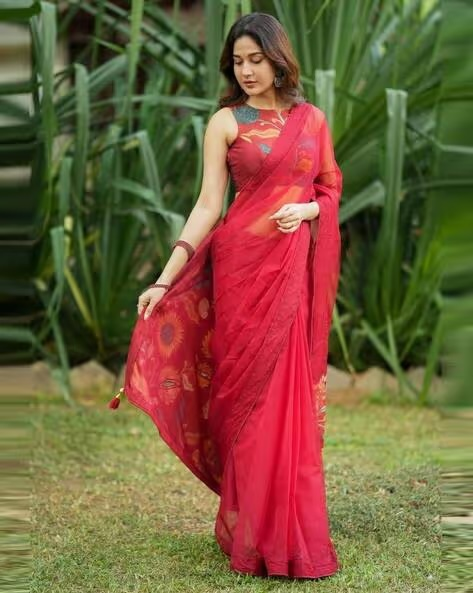

In [13]:
image = load_image(IMAGE_PATH)
display(image)



Running fashn_human_parser ...


Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

{
  "dress": 66479
}


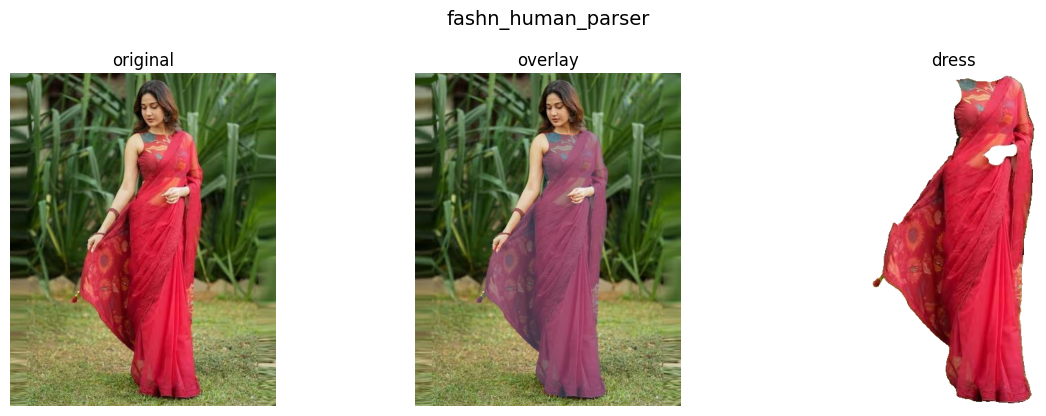

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

{
  "dress": 64198
}


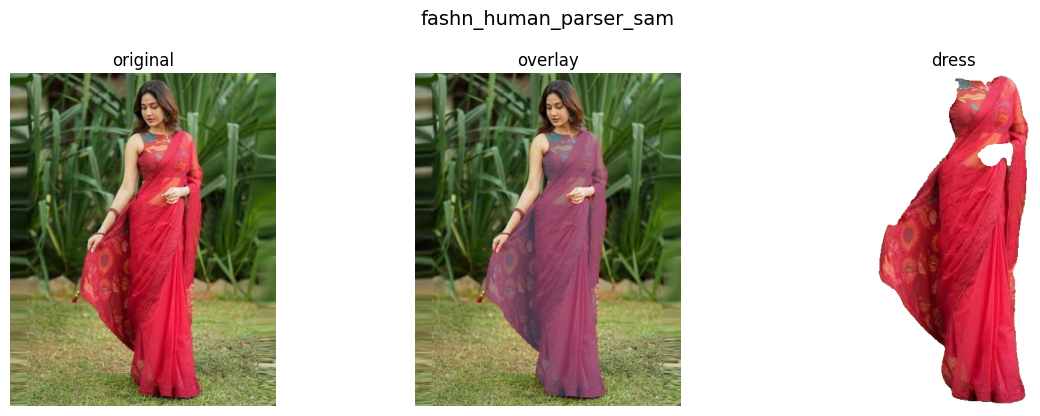


Running segformer_b2_clothes ...


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

{
  "dress": 65640
}


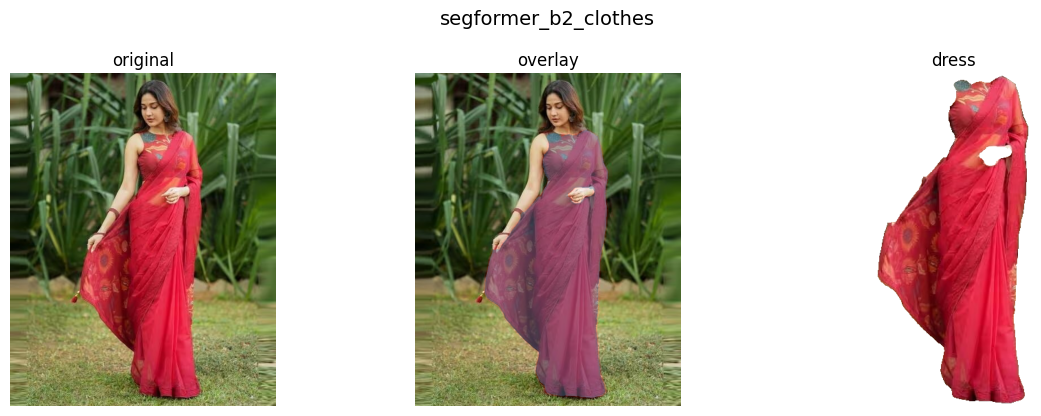

{
  "dress": 65327
}


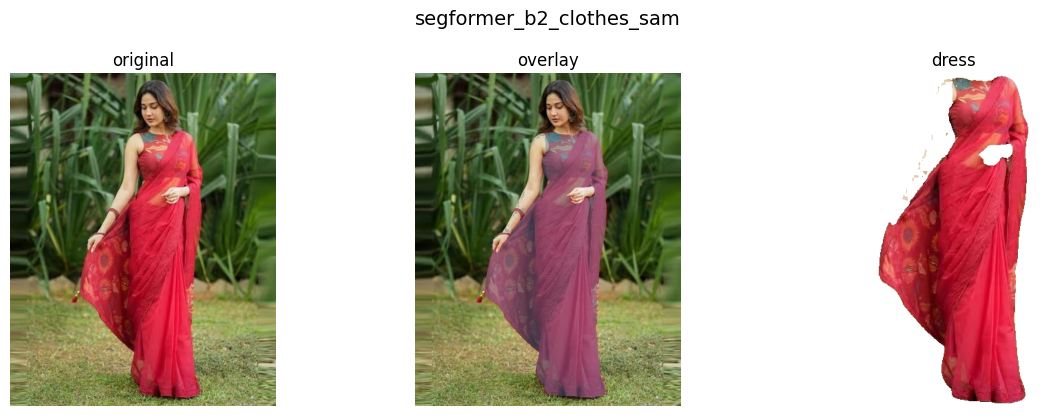

In [14]:
results: dict[str, dict[str, Any]] = {}
backend_failures: dict[str, str] = {}
backends_to_run = [*BASELINE_BACKENDS, *(OPTIONAL_BACKENDS if INCLUDE_OPTIONAL_BACKENDS else [])]

for backend_name in backends_to_run:
    print(f"\nRunning {backend_name} ...")
    result, error_message = try_run_semantic_backend(
        image,
        backend_name,
        min_pixels=MIN_ITEM_PIXELS,
    )
    if error_message is not None:
        backend_failures[backend_name] = error_message
        print(error_message)
        continue

    assert result is not None
    results[backend_name] = result
    print(json.dumps(result["summary"], indent=2))
    show_extractions(image, result["items"], title=backend_name)

    if RUN_SAM_REFINEMENT and result["items"]:
        refined_items, sam_details = refine_items_with_sam(
            image,
            result["items"],
            checkpoint=SAM_CHECKPOINT,
        )
        refined_key = f"{backend_name}_sam"
        results[refined_key] = {
            "backend": refined_key,
            "items": refined_items,
            "summary": summarize_items(refined_items),
            "sam_details": sam_details,
        }
        print(json.dumps(results[refined_key]["summary"], indent=2))
        show_extractions(image, refined_items, title=refined_key)

if backend_failures:
    print("\nSkipped backends:")
    print(json.dumps(backend_failures, indent=2))

if SHOW_SAM_AUTO_DIAGNOSTIC:
    show_sam_auto_masks(image, checkpoint=SAM_CHECKPOINT)


## Batch export

This writes extracted garments plus an aggregate manifest to `notebooks/outputs/clothes_extraction/manifest.json`.


In [15]:
BATCH_IMAGE_DIR = MODEL_IMAGE_DIR if image_paths(MODEL_IMAGE_DIR) else FALLBACK_IMAGE_DIR
BATCH_IMAGE_PATHS = image_paths(BATCH_IMAGE_DIR)
if not BATCH_IMAGE_PATHS:
    raise FileNotFoundError(f"No images found in {MODEL_IMAGE_DIR} or {FALLBACK_IMAGE_DIR}")

BATCH_BACKENDS = [*BASELINE_BACKENDS, *(OPTIONAL_BACKENDS if INCLUDE_OPTIONAL_BACKENDS else [])]
BATCH_INCLUDE_SAM = True

manifest: list[dict[str, Any]] = []
batch_failures: list[dict[str, str]] = []
started_at = time.time()

for image_path in BATCH_IMAGE_PATHS:
    image = load_image(image_path)
    print(f"Processing {image_path.name} ...")
    for backend_name in BATCH_BACKENDS:
        result, error_message = try_run_semantic_backend(
            image,
            backend_name,
            min_pixels=MIN_ITEM_PIXELS,
        )
        if error_message is not None:
            print(f"  skipping {backend_name}: {error_message}")
            batch_failures.append({"image": image_path.name, "backend": backend_name, "error": error_message})
            continue

        assert result is not None
        manifest.extend(save_item_crops(image_path, backend_name, image, result["items"]))

        if BATCH_INCLUDE_SAM and result["items"]:
            refined_items, _ = refine_items_with_sam(
                image,
                result["items"],
                checkpoint=SAM_CHECKPOINT,
            )
            manifest.extend(
                save_item_crops(image_path, f"{backend_name}_sam", image, refined_items)
            )

manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
if batch_failures:
    (OUTPUT_DIR / "failures.json").write_text(json.dumps(batch_failures, indent=2), encoding="utf-8")
elapsed = time.time() - started_at
print(f"Wrote {len(manifest)} extracted items to {manifest_path} in {elapsed:.1f}s")


Processing 1.jpeg ...
Processing 2.jpeg ...
Wrote 8 extracted items to /Users/mohitjoshi/Projects/fashion-app/notebooks/outputs/clothes_extraction/manifest.json in 25.9s


## Optional: Detectron2 fashion checkpoint hook

Off-the-shelf Detectron2 model-zoo checkpoints are usually not good enough for garment extraction from model photos because they are not fashion-specific. This hook is for the case where you already have a fashion segmentation checkpoint trained on something like DeepFashion2, ModaNet, or Fashionpedia.


In [16]:
DETECTRON2_CONFIG_FILE: str | None = None
DETECTRON2_WEIGHTS_FILE: str | None = None
DETECTRON2_CLASS_NAMES: list[str] | None = None
DETECTRON2_SCORE_THRESH = 0.4
DETECTRON2_ALLOWED_LABELS = {
    "top",
    "shirt",
    "blouse",
    "tee",
    "jacket",
    "coat",
    "dress",
    "skirt",
    "pants",
    "trousers",
    "belt",
    "scarf",
}


def normalize_detectron2_label(raw_label: str) -> str | None:
    text = raw_label.lower().strip()
    if any(token in text for token in ("shirt", "blouse", "tee", "sweater", "cardigan", "jacket", "coat", "vest", "top")):
        return "top"
    if "dress" in text or "jumpsuit" in text:
        return "dress"
    if "skirt" in text:
        return "skirt"
    if any(token in text for token in ("pant", "trouser", "jean", "short")):
        return "pants"
    if "belt" in text:
        return "belt"
    if "scarf" in text:
        return "scarf"
    return None


def run_detectron2_fashion_checkpoint(image_path: str | Path) -> dict[str, np.ndarray]:
    if not DETECTRON2_CONFIG_FILE or not DETECTRON2_WEIGHTS_FILE:
        raise ValueError("Set DETECTRON2_CONFIG_FILE and DETECTRON2_WEIGHTS_FILE first.")

    import cv2
    from detectron2.config import get_cfg
    from detectron2.data import MetadataCatalog
    from detectron2.engine import DefaultPredictor

    cfg = get_cfg()
    cfg.merge_from_file(str(DETECTRON2_CONFIG_FILE))
    cfg.MODEL.WEIGHTS = str(DETECTRON2_WEIGHTS_FILE)
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = DETECTRON2_SCORE_THRESH
    cfg.MODEL.DEVICE = DEVICE

    predictor = DefaultPredictor(cfg)
    bgr = cv2.imread(str(image_path))
    outputs = predictor(bgr)["instances"].to("cpu")

    class_names = DETECTRON2_CLASS_NAMES
    if class_names is None and cfg.DATASETS.TRAIN:
        metadata = MetadataCatalog.get(cfg.DATASETS.TRAIN[0])
        class_names = getattr(metadata, "thing_classes", None)

    items: dict[str, np.ndarray] = {}
    for cls_idx, score, mask in zip(outputs.pred_classes.tolist(), outputs.scores.tolist(), outputs.pred_masks):
        if score < DETECTRON2_SCORE_THRESH:
            continue
        raw_label = class_names[cls_idx] if class_names is not None else str(cls_idx)
        normalized_label = normalize_detectron2_label(raw_label)
        if normalized_label is None:
            continue
        items.setdefault(normalized_label, np.zeros(mask.shape, dtype=bool))
        items[normalized_label] |= to_numpy_mask(mask)
    return items


# Example usage after you set config + weights:
# det_items = run_detectron2_fashion_checkpoint(IMAGE_PATH)
# show_extractions(image, det_items, title="detectron2_custom_checkpoint")
